# Feature Distribution Supplement

**Owner: Student 3 | Review 1 - Dataset and EDA**  
This supplement adds the feature-by-feature distributions required by rubric A2. The existing regression EDA notebook already contains the target distribution, correlation heatmap, and two feature-target scatter plots.

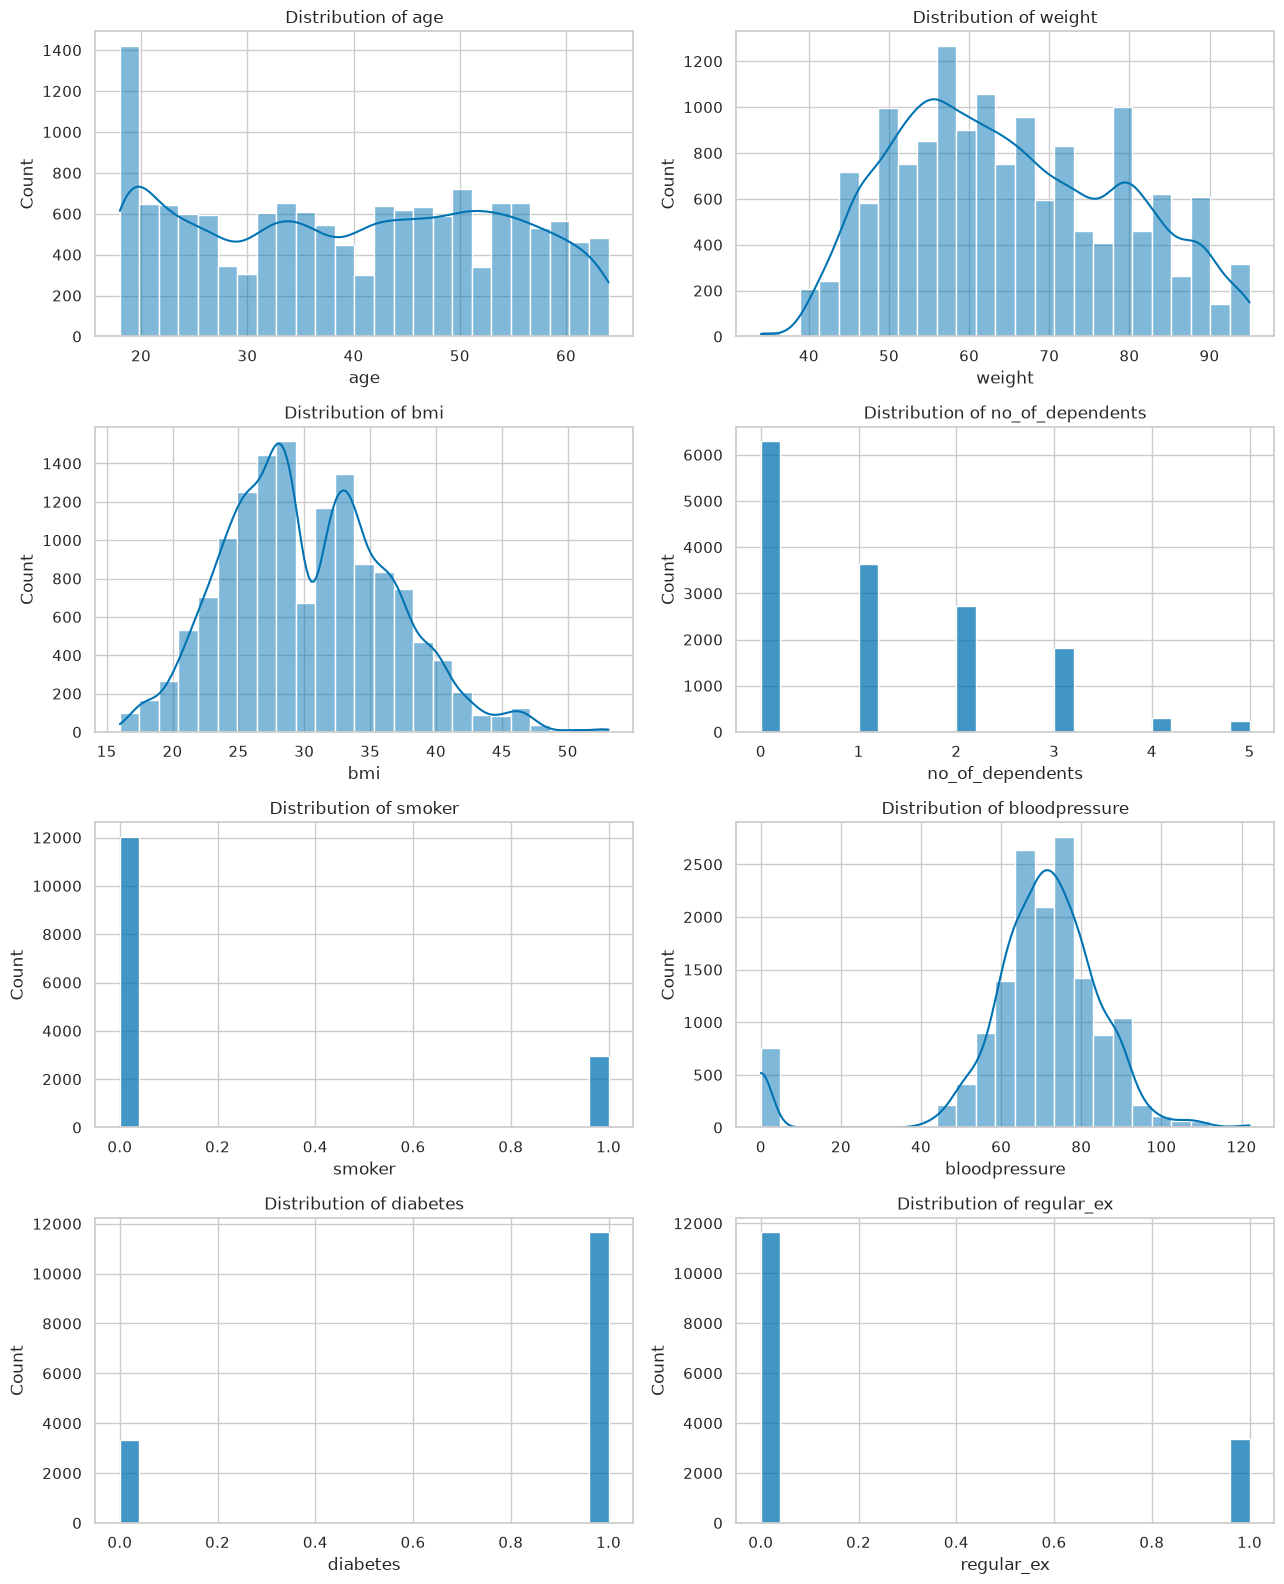

In [1]:
from pathlib import Path
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
repo_root = next(
    (parent for parent in (Path.cwd(), *Path.cwd().parents)
     if (parent / "data" / "health_insurance.csv").exists()),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Run this notebook from inside the ML-301 repository.")

df = pd.read_csv(repo_root / "data" / "health_insurance.csv")
features = df.drop(columns="claim")
numeric_features = features.select_dtypes(include="number").columns.tolist()
categorical_features = features.select_dtypes(exclude="number").columns.tolist()

fig, axes = plt.subplots(math.ceil(len(numeric_features) / 2), 2, figsize=(13, 16))
for column, ax in zip(numeric_features, axes.flat):
    sns.histplot(features[column], bins=25, kde=features[column].nunique() > 10, ax=ax)
    ax.set(title=f"Distribution of {column}", xlabel=column, ylabel="Count")
for ax in axes.flat[len(numeric_features):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

### Student observations required

Before submission, write your own observations for the numerical distributions above. Identify skew, missingness visible in the counts, unusual ranges, and binary-feature imbalance. Do not copy generated analysis.

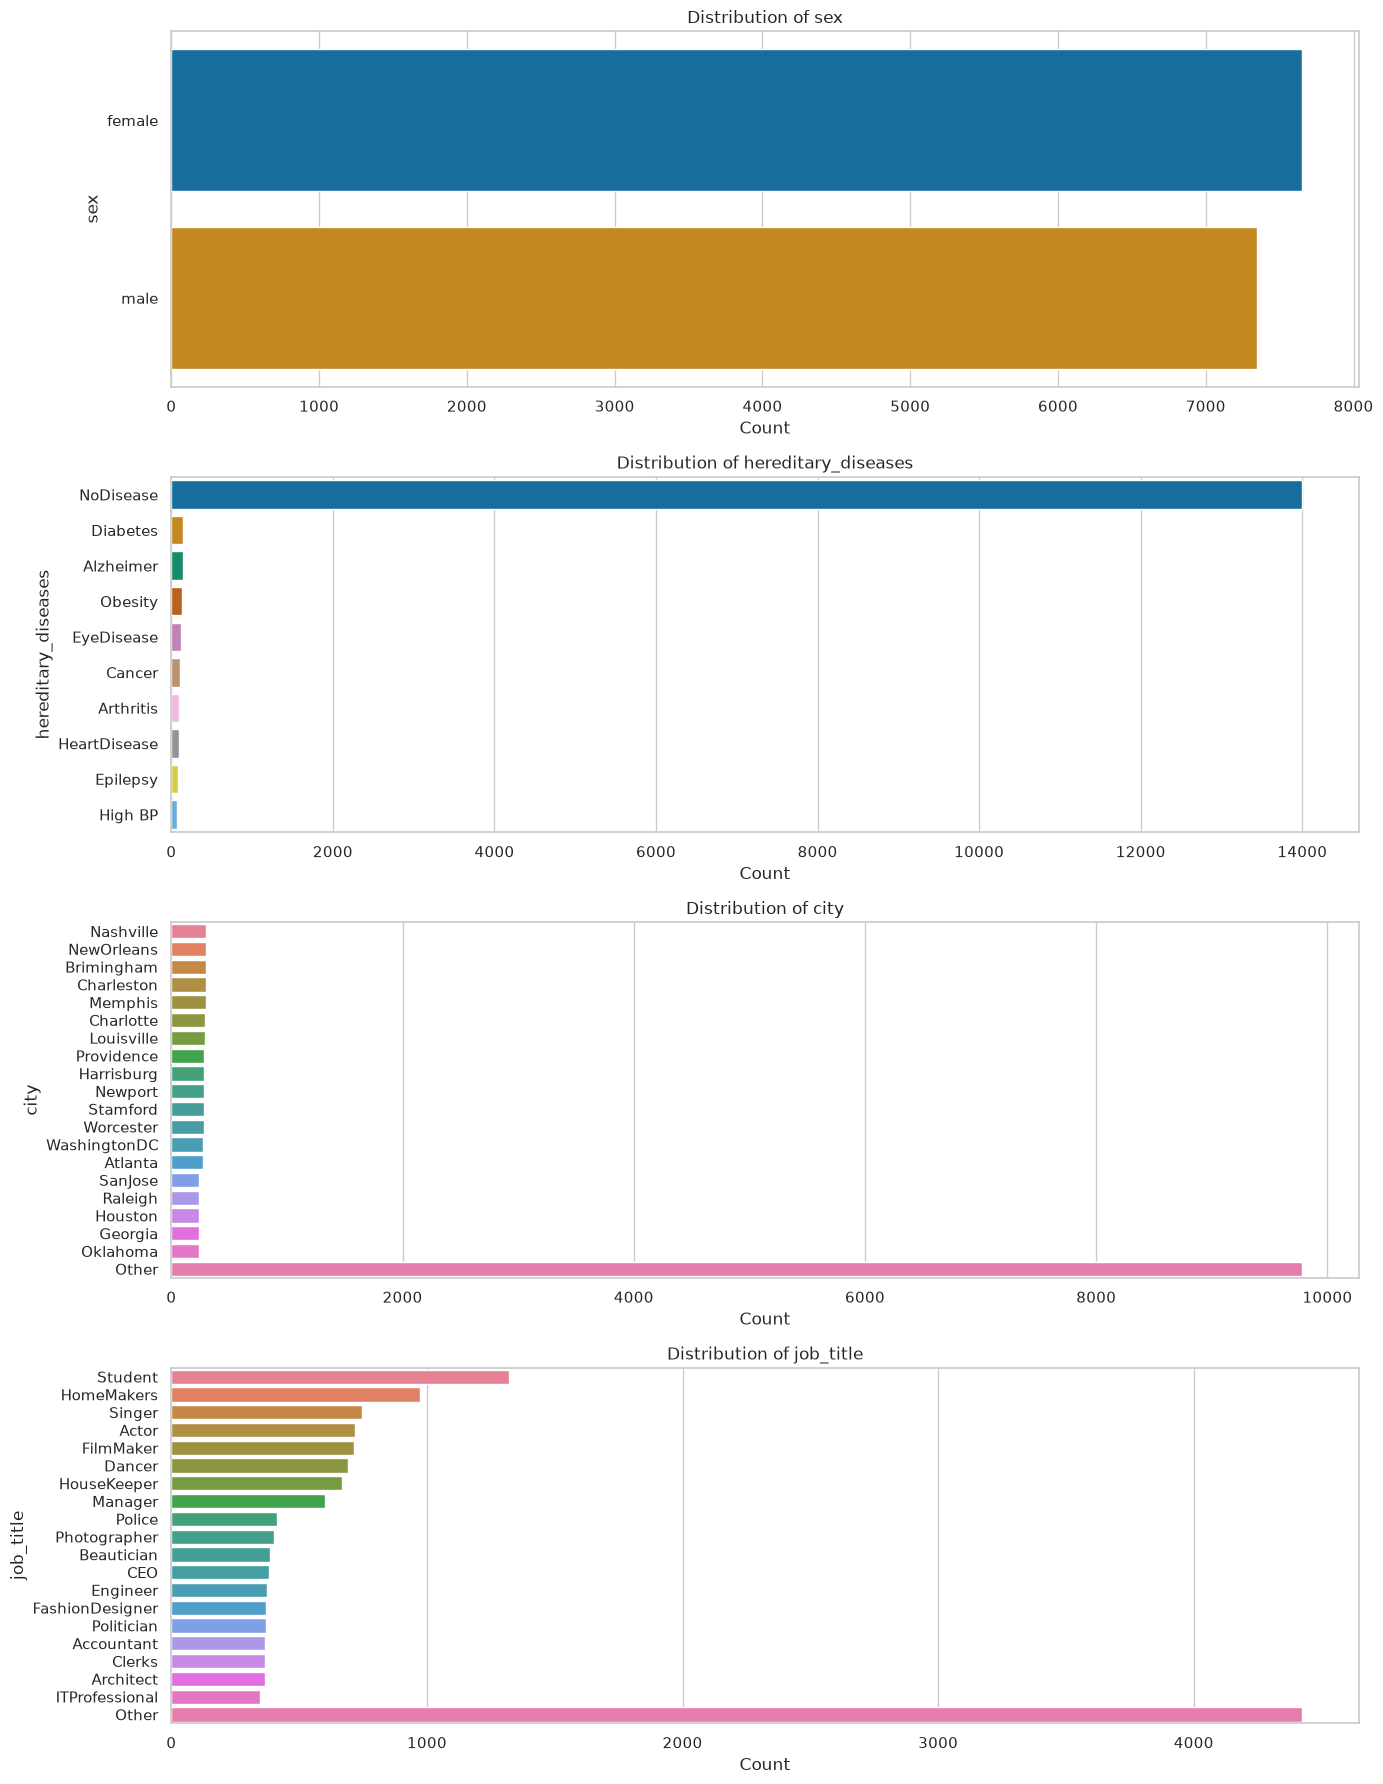

,count,unique,mean,std,min,max
age,14604.0,NaN,39.547521,14.015966,18.0,64.0
sex,15000,2,NaN,NaN,NaN,NaN
weight,15000.0,NaN,64.9096,13.701935,34.0,95.0
bmi,14044.0,NaN,30.266413,6.12295,16.0,53.1
hereditary_diseases,15000,10,NaN,NaN,NaN,NaN
no_of_dependents,15000.0,NaN,1.129733,1.228469,0.0,5.0
smoker,15000.0,NaN,0.198133,0.398606,0.0,1.0
city,15000,91,NaN,NaN,NaN,NaN
bloodpressure,15000.0,NaN,68.650133,19.418515,0.0,122.0
diabetes,15000.0,NaN,0.777,0.416272,0.0,1.0


In [2]:
fig, axes = plt.subplots(len(categorical_features), 1, figsize=(14, 18))
for column, ax in zip(categorical_features, axes):
    counts = features[column].value_counts()
    if len(counts) > 20:
        displayed = counts.head(19)
        displayed.loc["Other"] = counts.iloc[19:].sum()
    else:
        displayed = counts
    sns.barplot(x=displayed.values, y=displayed.index, hue=displayed.index, legend=False, ax=ax)
    ax.set(title=f"Distribution of {column}", xlabel="Count", ylabel=column)
plt.tight_layout()
plt.show()

display(features.describe(include="all").T[["count", "unique", "mean", "std", "min", "max"]])

### Student observations required

Before submission, write your own observations for the categorical distributions above. Discuss dominant and rare categories and whether any imbalance affects encoding or model evaluation. `Other` groups the tail only for readable plots; the models retain every original category.